<a href="https://colab.research.google.com/github/iav2002/Assignment_Advanced_Topics_In_DeepLearning/blob/main/demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import urllib.request
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [ ]:
URLS = {
    'resnet': 'https://github.com/iav2002/Assignment_Advanced_Topics_In_DeepLearning/releases/download/v1.0/par2_resnet50_best.pt',
    'embeddings': 'https://github.com/iav2002/Assignment_Advanced_Topics_In_DeepLearning/releases/download/v1.0/mean_embeddings.npy',
    'dqn': 'https://github.com/iav2002/Assignment_Advanced_Topics_In_DeepLearning/releases/download/v1.0/part3_dqn_v3_best.pt',
    'env': 'https://github.com/iav2002/Assignment_Advanced_Topics_In_DeepLearning/releases/download/v1.0/WarehouseEnv.py',
}

# download to /tmp so we don't pollute the working dir
TMP = Path(tempfile.gettempdir()) / 'demo_models'
TMP.mkdir(exist_ok=True)

for name, url in URLS.items():
    suffix = url.split('.')[-1]
    out = TMP / f'{name}.{suffix}'
    if not out.exists():
        print(f"Downloading {name}...")
        urllib.request.urlretrieve(url, out)
    else:
        print(f"{name} already cached.")

print("All files ready.")

resnet already cached.
All files ready.


## Part 2: ResNet50 classifier

We load the best ResNet50 from Part 2 (Variant C of the gradual unfreezing experiment, 99.05% test accuracy) and run it on a few test images. This is mostly a sanity check that the model loads correctly.

In [ ]:
# Part 2 demo: load best ResNet50 from Release, run inference on a few crops

import torchvision.models as models
from torchvision import transforms

# 11 classes from Part 2 EDA
IDX_TO_CLASS = {
    0: 'box', 1: 'ceiling', 2: 'floor', 3: 'floor_decal',
    4: 'lamp', 5: 'pallet', 6: 'pillar', 7: 'rack',
    8: 'sign', 9: 'wall', 10: 'wire',
}
NUM_CLASSES = len(IDX_TO_CLASS)

# imagenet normalization, same as during training
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
IMG_SIZE = 224

def build_resnet50(num_classes):
    """Same architecture as Part 2: resnet50 + 11-way fc head."""
    m = models.resnet50(weights=None)  # weights loaded from checkpoint below
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

# load checkpoint and rebuild
ckpt = torch.load(TMP / 'resnet.pt', map_location=device, weights_only=False)
model = build_resnet50(NUM_CLASSES).to(device)
model.load_state_dict(ckpt['model_state'])
model.eval()

print(f"Loaded ResNet50 checkpoint from epoch {ckpt['epoch']}")
print(f"Validation loss at save: {ckpt['val_loss']:.4f}")

# sanity forward pass on a dummy batch
with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
    out = model(dummy)
print(f"Dummy forward pass: output shape {tuple(out.shape)} (expected (2, {NUM_CLASSES}))")

# inference helper for any image url
preprocess = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def predict_from_url(url):
    """Download an image and return top-3 predicted classes."""
    from PIL import Image
    import io

    out_path = TMP / 'tmp_img.jpg'
    urllib.request.urlretrieve(url, out_path)
    img = Image.open(out_path).convert('RGB')

    x = preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
        probs = F.softmax(logits, dim=1)[0]

    top3 = torch.topk(probs, 3)
    preds = [(IDX_TO_CLASS[idx.item()], prob.item()) for idx, prob in zip(top3.indices, top3.values)]
    return img, preds


Loaded ResNet50 checkpoint from epoch 8
Validation loss at save: 0.0344
Dummy forward pass: output shape (2, 11) (expected (2, 11))

Ready. Use predict_from_url(url) to classify a warehouse crop.


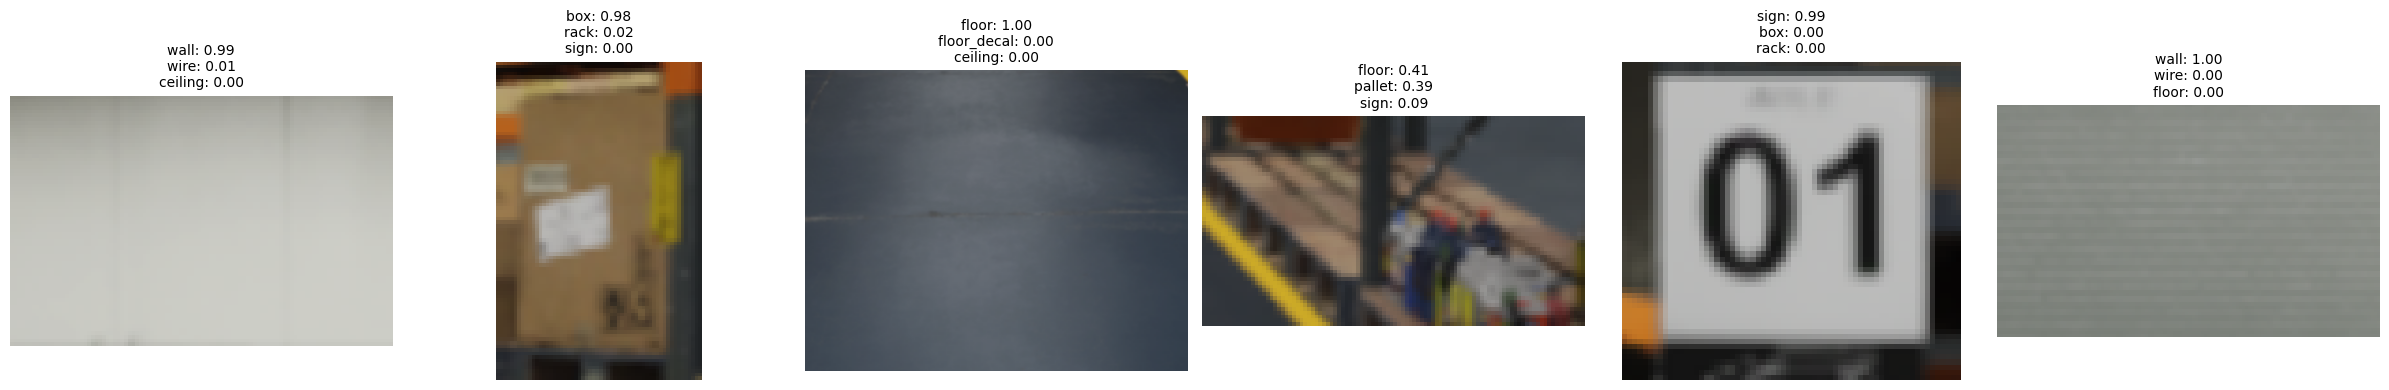

In [ ]:
# classify a few sample crops

SAMPLE_URLS = [

   'https://github.com/iav2002/Assignment_Advanced_Topics_In_DeepLearning/raw/main/images/Wall.png',
   'https://github.com/iav2002/Assignment_Advanced_Topics_In_DeepLearning/raw/main/images/box.png',
   'https://github.com/iav2002/Assignment_Advanced_Topics_In_DeepLearning/raw/main/images/floor.png',
   'https://github.com/iav2002/Assignment_Advanced_Topics_In_DeepLearning/raw/main/images/pallet.png',
   'https://github.com/iav2002/Assignment_Advanced_Topics_In_DeepLearning/raw/main/images/signImage.png',
   'https://github.com/iav2002/Assignment_Advanced_Topics_In_DeepLearning/raw/main/images/wallImage.png'

]

if SAMPLE_URLS:
    fig, axes = plt.subplots(1, len(SAMPLE_URLS), figsize=(4 * len(SAMPLE_URLS), 4))
    if len(SAMPLE_URLS) == 1:
        axes = [axes]
    for ax, url in zip(axes, SAMPLE_URLS):
        img, preds = predict_from_url(url)
        ax.imshow(img)
        title = '\n'.join(f'{cls}: {p:.2f}' for cls, p in preds)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## Part 3: DQN agent on the warehouse grid

We load the best DQN V3 model and run it on the 5x5 warehouse grid for a few episodes, visualizing the trajectory the agent takes.

In [ ]:
if 'env' in sys.modules:
    del sys.modules['env']

In [32]:
import sys
import random as rnd
import importlib

# add the env source so we can import it
sys.path.insert(0, str(TMP))
if 'env' in sys.modules:
    importlib.reload(sys.modules['env'])
from env import WarehouseEnv

# rebuild the same network architecture used in training
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, action_dim)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

# load checkpoint and rebuild model
ckpt = torch.load(TMP / 'dqn.pt', map_location=device, weights_only=False)
net = QNetwork(ckpt['state_dim'], ckpt['action_dim'], ckpt['hidden']).to(device)
net.load_state_dict(ckpt['state_dict'])
net.eval()
print(f"Loaded V3 model: {ckpt['final_success']:.2%} success, {ckpt['final_ep_length']:.1f} avg steps")

# load embeddings
emb_str = np.load(TMP / 'embeddings.npy', allow_pickle=True).item()
NAME_TO_ID = {'floor': 0, 'wall': 1, 'pallet': 2, 'sign': 3}
emb = {NAME_TO_ID[k]: v.astype(np.float32) for k, v in emb_str.items()}

# rebuild the same grid used in Part 3 training
GRID = [
    [0, 0, 1, 0, 0],
    [1, 0, 1, 0, 1],
    [0, 0, 3, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 2],
]

env = WarehouseEnv(grid_map=GRID, embeddings_dict=emb)


# keep paths readable
def pos_tuple(pos):
    return (int(pos[0]), int(pos[1]))


# collect all valid start positions, floor or sign tiles, excluding the pallet
valid_starts = []
for y in range(len(GRID)):
    for x in range(len(GRID[0])):
        if GRID[y][x] in (0, 3):  # floor or sign, not wall, not pallet
            valid_starts.append((x, y))

print(f"\nRunning 25 demo episodes from random start positions.")
print("Agent was trained only from (0,0) so will be interesting")

rnd.seed(7)  # fixed seed so the demo is reproducible

successes = 0
for ep in range(25):
    obs, _ = env.reset()

    # override agent_pos to a random valid start, refresh observation
    sx, sy = rnd.choice(valid_starts)
    env.agent_pos = np.array([sx, sy])
    obs = env._get_obs()

    trajectory = [pos_tuple(env.agent_pos)]
    total_reward = 0.0
    for t in range(100):
        with torch.no_grad():
            s = torch.from_numpy(obs).float().unsqueeze(0).to(device)
            action = int(net(s).argmax(dim=1).item())
        obs, reward, term, trunc, _ = env.step(action)
        total_reward += reward
        trajectory.append(pos_tuple(env.agent_pos))
        if term or trunc:
            break

    status = "REACHED PALLET" if term else "timed out"
    if term:
        successes += 1
    print(f"  Ep {ep+1:2d}: start {trajectory[0]}, {len(trajectory)-1} steps, "
          f"reward {total_reward:.2f}, {status}")
    print(f"    Path: {' -> '.join(str(p) for p in trajectory)}")

print(f"\nGeneralization summary: {successes}/25 episodes reached the pallet "
      f"({successes/25:.0%} success rate from random starts).")

Loaded V3 model: 100.00% success, 10.1 avg steps

Running 25 demo episodes from random start positions.
Agent was trained only from (0,0) so will be interesting
  Ep  1: start (4, 2), 2 steps, reward 9.95, REACHED PALLET
    Path: (4, 2) -> (4, 3) -> (4, 4)
  Ep  2: start (1, 1), 6 steps, reward 9.75, REACHED PALLET
    Path: (1, 1) -> (1, 2) -> (2, 2) -> (3, 2) -> (4, 2) -> (4, 3) -> (4, 4)
  Ep  3: start (4, 3), 1 steps, reward 10.00, REACHED PALLET
    Path: (4, 3) -> (4, 4)
  Ep  4: start (1, 0), 7 steps, reward 9.70, REACHED PALLET
    Path: (1, 0) -> (1, 1) -> (1, 2) -> (2, 2) -> (3, 2) -> (4, 2) -> (4, 3) -> (4, 4)
  Ep  5: start (3, 0), 5 steps, reward 9.80, REACHED PALLET
    Path: (3, 0) -> (3, 1) -> (3, 2) -> (4, 2) -> (4, 3) -> (4, 4)
  Ep  6: start (4, 0), 6 steps, reward 9.75, REACHED PALLET
    Path: (4, 0) -> (3, 0) -> (3, 1) -> (3, 2) -> (4, 2) -> (4, 3) -> (4, 4)
  Ep  7: start (0, 3), 7 steps, reward 9.70, REACHED PALLET
    Path: (0, 3) -> (0, 2) -> (1, 2) -> (2, 2)